In [29]:
import pandas as pd
import requests
import io
import json
import numpy as np
from fpdf import FPDF
import seaborn as sns
from matplotlib import pyplot as plt
import matplotlib.dates as md
from fpdf import FPDF
from matplotlib.ticker import FuncFormatter
import matplotlib.ticker as ticker
import plotly.graph_objects as go
import plotly.express as px
import plotly.offline as pyo




In [31]:
report_type= 'class'
# first_Period= '2023'
# second_Period= '2024'
first_period_min= '2023-01-01'
first_period_max= '2023-12-31'
second_period_min= '2024-01-01'
second_period_max= '2024-12-31'
#vessel_name= 'HOSHI - 9453298'
#fleet= 'Fleet 1'
class_name: 'Aby'
moving_average= '1'
#moving_average: 1




In [33]:
import json 

text_file_path = 'eeoi_pc_class.txt'

# Read the content of the text file and load it into a JSON object
with open(text_file_path, 'r') as file:
    s = json.load(file)  
# Now, you can use the 's' variable to work with your JSON data
print(s)

{'data': {'year1': {'finaldata': [{'imo': '9120841', 'vessel_name': 'MSC DOMNA X', 'fleet': '14', 'class': 'ABY', 'distance_covered': 78023.6, 'fuel_boiler_dstlt_uls': 0, 'fuel_aux_dstlt_uls': 0, 'teu_transport_work': 1111489195.2, 'cargo_transport_work': 10819940221.9, 'fuel_boiler_tnktnr_dstlt_vls': 148.68, 'fuel_aux_tnktnr_dstlt_vls': 356.9, 'fuel_me_tnktnr_dstlt_vls': 755.75, 'fuel_me_dstlt_uls': 0, 'fuel_boiler_dstlt_vls': 0, 'fuel_aux_dstlt_vls': 0, 'fuel_me_dstlt_vls': 0, 'fuel_boiler_rsdl_uls': 0, 'fuel_aux_rsdl_uls': 0, 'fuel_me_rsdl_uls': 0, 'fuel_boiler_rsdl_vls': 364.36, 'fuel_aux_rsdl_vls': 2766.95, 'fuel_me_rsdl_vls': 14525.65, 'fuel_boiler_rsdl_hs': 0, 'fuel_aux_rsdl_hs': 0, 'fuel_me_rsdl_hs': 0, 'miles_by_gps': 72197, 'manvrng_miles_by_gps': 5826.6, 'fuel_hs': 0, 'fuel_ls': 17656.96, 'fuel_mdo': 0, 'fuel_mgo': 1261.33, 'fuel_mgo_ls': 0, 'me_fuel_only_steaming_time': 377.5, 'fuel_me_hs': 0, 'fuel_aux_hs': 0, 'fuel_boiler_hs': 0, 'fuel_me_ls': 1015.3, 'fuel_aux_ls': 138.2

In [35]:
import pandas as pd
from datetime import datetime



vsl_name = pd.DataFrame.from_dict(s['vessel_data'])  
col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))  
if first_Period is None and second_Period is None:  
    date_object_first_Period = datetime.strptime(first_period_max, '%Y-%m-%d')
    first_Period_year = date_object_first_Period.year
    date_object_second_Period = datetime.strptime(second_period_max, '%Y-%m-%d')
    second_Period_year = date_object_second_Period.year
    Heading = "YEAR" + "  " + str(first_Period_year) + " - " + str(second_Period_year) + "  " + "EEOI ANALYSIS"
else:
    Heading = "YEAR" + "  " + first_Period + " - " + second_Period + "  " + "EEOI ANALYSIS"
    first_Period_year, second_Period_year = first_Period, second_Period


# if report_type == 'vessel':
#     # vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
#     # col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
#     s = s['data'] 



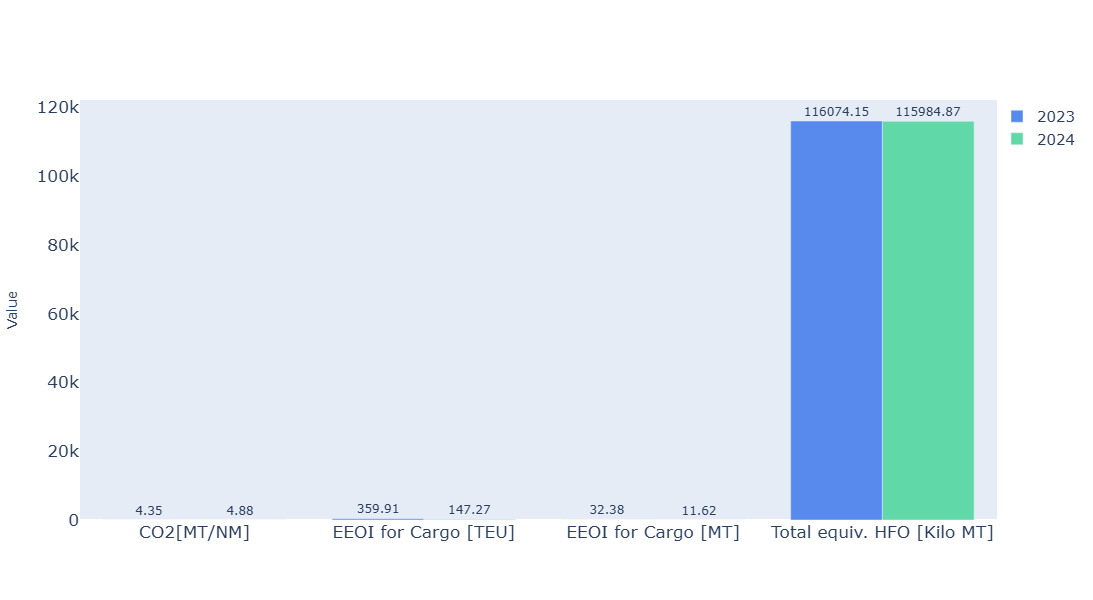

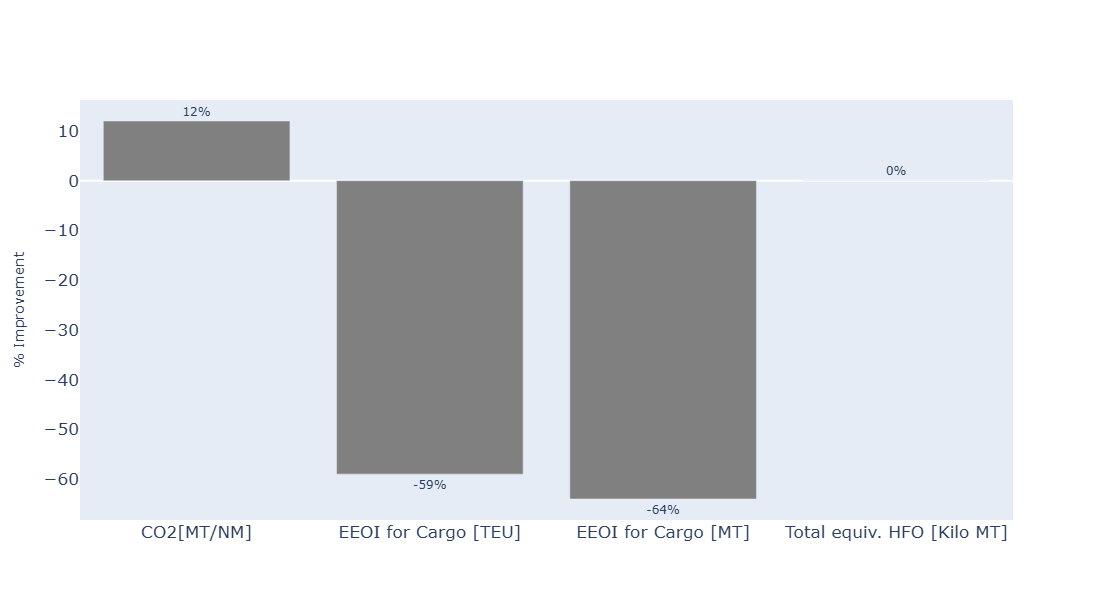

C:\Users\akshaya\AppData\Local\Temp\ipykernel_460604\3407536116.py:141: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



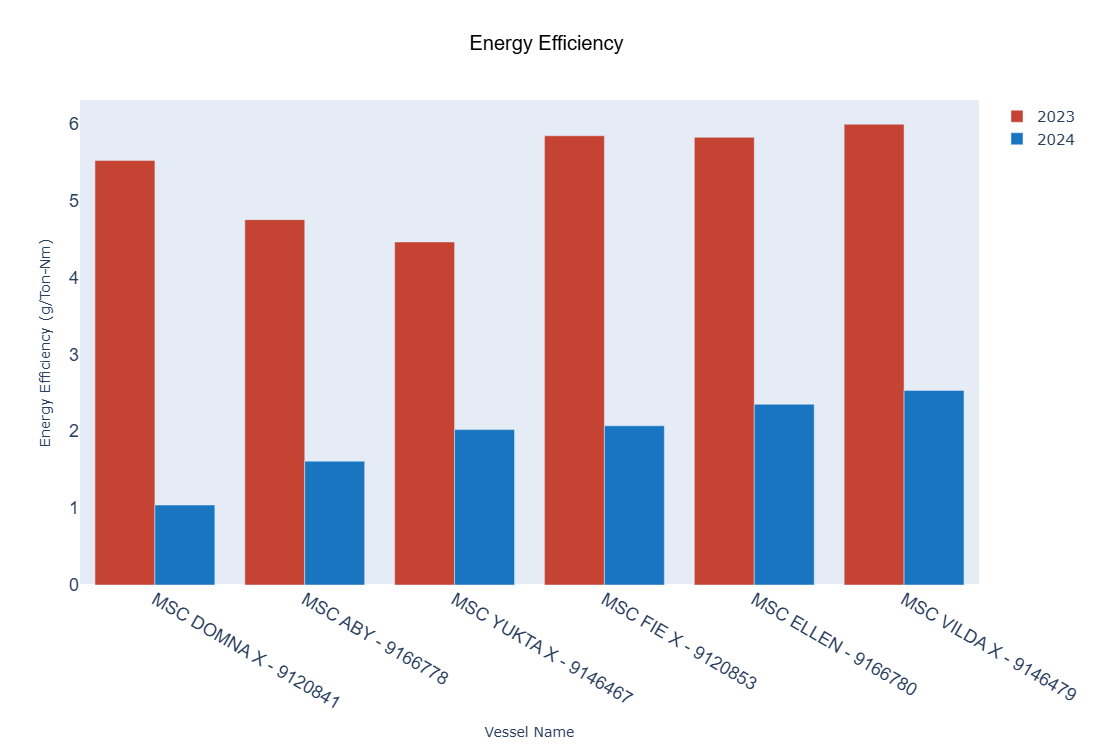

C:\Users\akshaya\AppData\Local\Temp\ipykernel_460604\3407536116.py:214: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



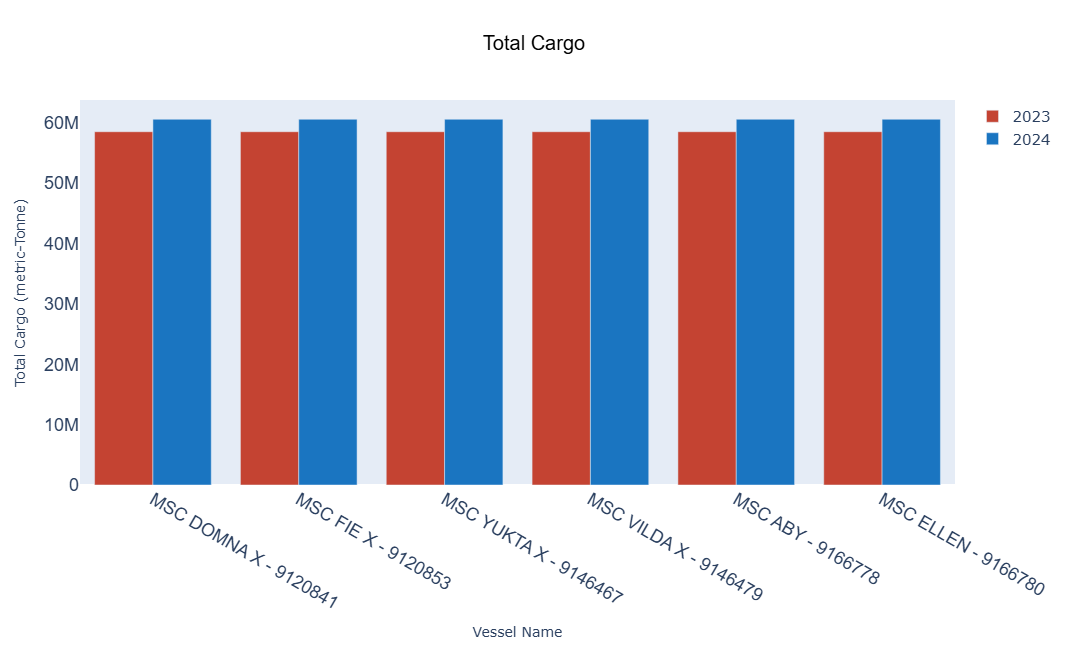

C:\Users\akshaya\AppData\Local\Temp\ipykernel_460604\3407536116.py:305: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



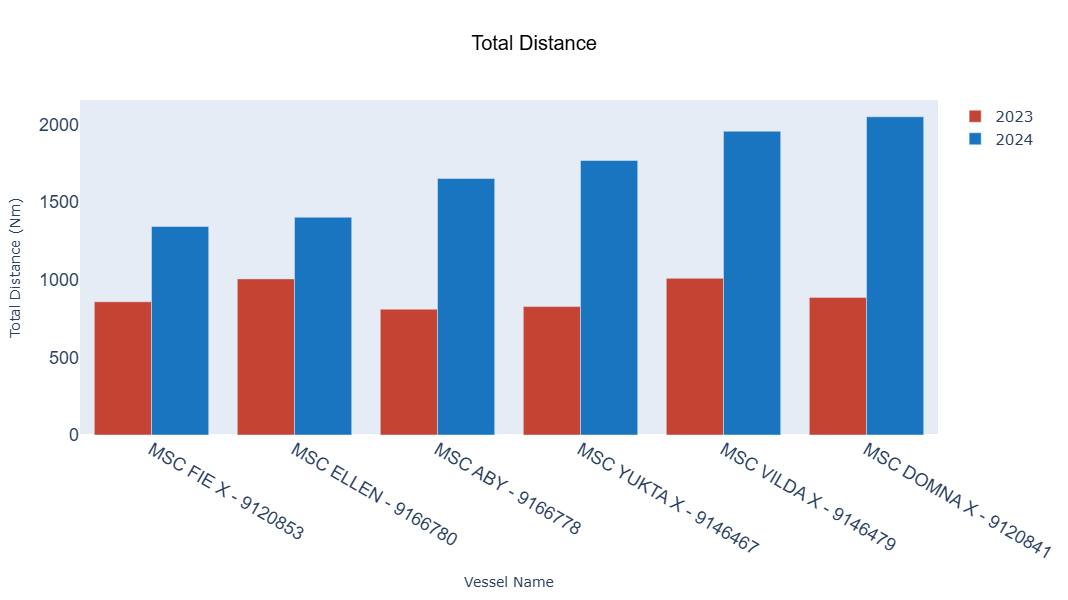

In [37]:
if report_type== 'class':
    vsl_name = pd.DataFrame.from_dict(s['vessel_data'])
    col_vsl = dict(zip(vsl_name['imo'], vsl_name['name']))
    #s = s['data']

    Table1 = pd.DataFrame.from_dict(s['data']['table1']['table1']).fillna(0)
    Table1['improvement'] = Table1['improvement'].astype(float).astype(int)
    Table1_str = Table1[['index', 'year1', 'year2', 'improvement']].astype(str)
    Table1_str['improvement'] = Table1_str['improvement'] + ' %'

    Table_1_head_Year = [['Year', first_Period, second_Period, '% Improvement']] if all((first_Period, second_Period)) else [['Year', str(first_Period_year), str(second_Period_year), '% Improvement']]
    Table_1_Year = Table_1_head_Year + Table1_str.values.tolist()

    # 2nd Table
    Table_2 = Table1.set_index(['index'])
    Table_2 = Table_2.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]].reset_index()

    Table_2 = Table_2.rename({'improvement': 'Improvement (%)', 'year1': first_Period, 'year2': second_Period, 'index': 'Year'}, axis=1) if all((first_Period, second_Period)) else Table_2.rename({'improvement': 'Improvement (%)', 'year1': str(first_Period_year), 'year2': str(second_Period_year), 'index': 'Year'}, axis=1)

    Table_2_new = Table_2.T.reset_index().T.set_index(0).T
    Table_2_str = Table_2_new.astype(str)
    
    FirstPeriodData = pd.DataFrame.from_dict(s['data']['FirstPeriodData'])
    FirstPeriodData_1 = FirstPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    # FirstPeriodData_1['eeoi_mt'] = FirstPeriodData_1['eeoi_mt'].astype('float32')
    # FirstPeriodData_1['eeoi_teu'] = FirstPeriodData_1['eeoi_teu'].astype('float32')
    FirstPeriodData_str = FirstPeriodData_1.astype(str)
    SecondPeriodData = pd.DataFrame.from_dict(s['data']['SecondPeriodData'])
    SecondPeriodData['Vessel Name'].nunique()
    SecondPeriodData_1 = SecondPeriodData[['Vessel Name', 'Cargo Total (MT)', 'Cargo Total (TEU)', 'Distance (NM)','Number of Voyages','Total CO2 (MT)',
                                    'Equivalent HFO (MT)','EEOI (gm/MT-NM)', 'EEOI (gm/TEU-NM)','Fuel per Miles(Kg/NM)','Distance per Voyage (NM)',
                                    'Fuel Consumption per Voyage (MT)']].round(2)
    SecondPeriodData_str = SecondPeriodData_1.astype(str)


    Year1_Graph = pd.DataFrame.from_dict(s['data']['year1']['finaldata']).round(2)
    Year2_Graph = pd.DataFrame.from_dict(s['data']['year2']['finaldata']).round(2)
    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_new = EEOI_Analysis.rename({"year1": first_Period, 'year2': second_Period}, axis=1) if all((first_Period, second_Period)) else EEOI_Analysis.rename({"year1": str(first_Period_year), 'year2': str(second_Period_year)}, axis=1)

        # EEOI_Analysis_Graph = EEOI_Analysis_new.plot.bar(rot=0, color={first_Period: "#588aee", second_Period: "#61d8a8"}, width=0.8, figsize=(10, 6))

    EEOI_Analysis = Table1.set_index(['index'])
    EEOI_Analysis = EEOI_Analysis.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    EEOI_Analysis = EEOI_Analysis[['year1', 'year2']]

    EEOI_Analysis_1 = EEOI_Analysis_new.columns[0]
    EEOI_Analysis_2 = EEOI_Analysis_new.columns[1]

    # Create a bar chart for each trace with values above the bars
    trace1 = go.Bar(
    x=EEOI_Analysis.index,
    y=EEOI_Analysis['year1'],
    text=EEOI_Analysis['year1'].round(2),  # Adjust rounding as needed
    textposition='outside',  # Display text labels outside the bars
    name=EEOI_Analysis_1,
    marker=dict(color="#588aee")
    )

    trace2 = go.Bar(
    x=EEOI_Analysis.index,
    y=EEOI_Analysis['year2'],
    text=EEOI_Analysis['year2'].round(2),
    textposition='outside',
    name=EEOI_Analysis_2,  # Use the dynamically generated legend label
    marker=dict(color="#61d8a8")
    )

    layout = go.Layout(
    xaxis=dict(
        title=' ',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    yaxis=dict(
        title='Value',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    showlegend=True,
    legend=dict(
        x=1,  # Adjust the x position of the legend
        y=1,  # Adjust the y position of the legend
        font=dict(size=15),  # Adjust the font size of the legend
        bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
    ),
    width=1050,
    height=600
    )

    fig = go.Figure(data=[trace1, trace2], layout=layout)
    fig.show()
    plot_div = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})

    Improvement_Percent = Table1.set_index(['index'])
    Improvement_Percent = Improvement_Percent.loc[["CO2[MT/NM]", "EEOI for Cargo [TEU]",'EEOI for Cargo [MT]',"Total equiv. HFO [Kilo MT]"]]
    Improvement_Percent = Improvement_Percent[['improvement']].reset_index()
    Improvement_Percent = Improvement_Percent.set_index(['index'])

    fig = go.Figure()

    fig.add_trace(go.Bar(
    x=Improvement_Percent.index,
    y=Improvement_Percent['improvement'],
    text=Improvement_Percent['improvement'].astype('str') + '%',
    textposition='outside',  # Display text outside the bar
    marker=dict(color='#808080')  
    ))

    layout = go.Layout(
    xaxis=dict(
        title='',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    yaxis=dict(
        title='% Improvement',
        tickfont=dict(size=17),
        showgrid=False  # Correct syntax for showgrid
    ),
    showlegend=False,
    width=1000,
    height=600
    )
    # Format y-axis tick labels as percentages
    layout['yaxis']['tickformat'] = '.3f%'

    fig.update_layout(layout)

    fig.show()

    plot_div2 = pyo.plot(fig, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})
    
    Energy_Efficiency=Year1_Graph[['imo','eeoi_mt']]
    if second_Period != None:
        Energy_Efficiency[second_Period] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency=Energy_Efficiency.sort_values(by=second_Period)
    else:
        Energy_Efficiency[str(second_Period_year)] = Energy_Efficiency['imo'].map(Year2_Graph.set_index('imo')['eeoi_mt'])
        Energy_Efficiency=Energy_Efficiency.sort_values(by= str(second_Period_year))



    Energy_Efficiency['Vessel Name'] = Energy_Efficiency['imo'].map(col_vsl)
    Energy_Efficiency['Vessel - IMO']= Energy_Efficiency['Vessel Name']
    Energy_Efficiency=Energy_Efficiency.rename({'eeoi_mt': str(first_Period_year)},axis=1)

    if (first_Period and second_Period) != None:
       melted_data = pd.melt(Energy_Efficiency, id_vars=['Vessel - IMO'], value_vars=[first_Period, second_Period], var_name='Year', value_name='Energy_Efficiency')
       Energy_Efficiency_graph = px.bar(
            melted_data,
            x='Vessel - IMO',
            y='Energy_Efficiency',
            color='Year',
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )

    else:
        Energy_Efficiency_graph = px.bar(
            Energy_Efficiency,
            x='Vessel - IMO',
            y=[str(first_Period_year), str(second_Period_year)],
            color_discrete_sequence=['#c44332', '#1a75c1'],  # Medium red and blue
            labels={'value': 'Energy Efficiency (g/Ton-Nm)'},
            title='Energy Efficiency',
        )


    # Update the layout
    layout = go.Layout(
    title=dict(
        text='Energy Efficiency',
        font=dict(size=20, family='Roboto, sans-serif', color='black'),
        x=0.5  # Center the title horizontally
    ),
    xaxis=dict(
        title='Vessel Name',
        tickfont=dict(size=18, family='Roboto, sans-serif'),
        showgrid=False  # Correct syntax for showgrid
    ),
    yaxis=dict(
        title='Energy Efficiency (g/Ton-Nm)',
        tickfont=dict(size=18, family='Roboto, sans-serif'),
        showgrid=False  # Correct syntax for showgrid
    ),
    legend=dict(
        title='',  # Set an empty string to remove the legend title
        font=dict(size=15),  # Adjust the font size of the legend
        bgcolor='rgba(0, 0, 0, 0)'  # Make the legend background transparent
    ),
    barmode='group',  # 'group' for grouped bars
    width=1050,
    height=750
    )

    Energy_Efficiency_graph.update_layout(layout)
    Energy_Efficiency_graph.show()

    plot_div5 = pyo.plot(Energy_Efficiency_graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})


    # Extract the required columns
    Total_Cargo = Year1_Graph[['imo', 'cargomt']]
    
    # Handle the second period's data
    if second_Period:
        Total_Cargo[str(second_Period_year)] = Total_Cargo['imo'].map(Year2_Graph.set_index('imo')['cargomt'])
        Total_Cargo = Total_Cargo.sort_values(by=str(second_Period_year))
    else:
        Total_Cargo[str(second_Period_year)] = Total_Cargo['imo'].map(Year2_Graph.set_index('imo')['cargomt'])
        Total_Cargo = Total_Cargo.sort_values(by=str(second_Period_year))
    
    # Map Vessel Names
    Total_Cargo['Vessel Name'] = Total_Cargo['imo'].map(col_vsl)
    Total_Cargo['Vessel - IMO'] = Total_Cargo['Vessel Name']

    
    
    # Handle the first period column renaming
    if first_Period != 'null':
        Total_Cargo = Total_Cargo.rename({'cargomt': first_Period}, axis=1)
        y_columns = [first_Period, str(second_Period_year)] if second_Period else [first_Period]
        color_sequence = ['#c44332', '#1a75c1'] if second_Period else ['#c44332']
    else:
        Total_Cargo = Total_Cargo.rename({'cargomt': str(first_Period_year)}, axis=1)
        y_columns = [str(first_Period_year), str(second_Period_year)] if second_Period else [str(first_Period_year)]
        color_sequence = ['#c44332', '#1a75c1'] if second_Period else ['#c44332']

    # Melt the DataFrame for Plotly
    Total_Cargo_melted = Total_Cargo.melt(
        id_vars=['Vessel - IMO'], 
        value_vars=y_columns, 
        var_name='Year', 
        value_name='Total Cargo (metric-Tonne)'
    )
    
    # Update the 'Year' column to ensure it contains proper labels
    Total_Cargo_melted['Year'] = Total_Cargo_melted['Year'].astype(str)
    
    # Create the grouped bar chart
    Total_Cargo_Graph = px.bar(
        Total_Cargo_melted,
        x='Vessel - IMO',
        y='Total Cargo (metric-Tonne)',
        color='Year',  # Use 'Year' as the legend and hover variable
        barmode='group',
        color_discrete_sequence=color_sequence,
        labels={
            'Total Cargo (metric-Tonne)': 'Total Cargo (metric-Tonne)',  # Adjust y-axis label
            'Year': 'Year'  # Legend and hover label for years
        },
        title='Total Cargo'
    )

    
    # Update layout
    layout_total_cargo = go.Layout(
        title=dict(
            text='Total Cargo',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        yaxis=dict(
            title='Total Cargo (metric-Tonne)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False
        ),
        legend=dict(
            title='',
            font=dict(size=15),
            bgcolor='rgba(0, 0, 0, 0)'
        ),
        width=1050,
        height=650
    )
    
    # Apply layout and display the chart
    Total_Cargo_Graph.update_layout(layout_total_cargo)
    Total_Cargo_Graph.show()
    
    # Generate HTML div for embedding
    plot_div7 = pyo.plot(
        Total_Cargo_Graph,
        include_plotlyjs=True,
        output_type='div',
        config={'displayModeBar': False}
    )
    

    Total_Distance = Year1_Graph[['imo', 'average_distance']]
    
    if second_Period:
        Total_Distance[str(second_Period_year)] = Total_Distance['imo'].map(Year2_Graph.set_index('imo')['average_distance'])
        Total_Distance = Total_Distance.sort_values(by=str(second_Period_year))
    else:
        Total_Distance[str(second_Period_year)] = Total_Distance['imo'].map(Year2_Graph.set_index('imo')['average_distance'])
        Total_Distance = Total_Distance.sort_values(by=str(second_Period_year))
    
    # Map Vessel Names
    Total_Distance['Vessel Name'] = Total_Distance['imo'].map(col_vsl)
    Total_Distance['Vessel - IMO'] = Total_Distance['Vessel Name']
    
    # Handle the first period column renaming
    if first_Period != 'null':
        Total_Distance = Total_Distance.rename({'average_distance': first_Period}, axis=1)
        y_columns = [first_Period, str(second_Period_year)] if second_Period else [first_Period]
        color_sequence = ['#c44332', '#1a75c1'] if second_Period else ['#c44332']
    else:
        Total_Distance = Total_Distance.rename({'average_distance': str(first_Period_year)}, axis=1)
        y_columns = [str(first_Period_year), str(second_Period_year)] if second_Period else [str(first_Period_year)]
        color_sequence = ['#c44332', '#1a75c1'] if second_Period else ['#c44332']
    
    # Melt the DataFrame for Plotly
    Total_Distance_melted = Total_Distance.melt(
        id_vars=['Vessel - IMO'], 
        value_vars=y_columns, 
        var_name='Year', 
        value_name='Total Distance (Nm)'
    )
    
    # Update the 'Year' column to ensure it contains proper labels
    Total_Distance_melted['Year'] = Total_Distance_melted['Year'].astype(str)
    
    # Plotly bar chart for Total Distance
    Total_Distance_Graph = px.bar(
        Total_Distance_melted,
        x='Vessel - IMO',
        y='Total Distance (Nm)',
        color='Year',  # Use 'Year' as the legend and hover variable
        barmode='group',
        color_discrete_sequence=color_sequence,
        labels={
            'Total Distance (Nm)': 'Total Distance (Nm)',  # Adjust y-axis label
            'Year': 'Year'  # Legend and hover label for years
        },
        title='Total Distance'
    )
    
    # Update the layout
    layout_total_distance = go.Layout(
        title=dict(
            text='Total Distance',
            font=dict(size=20, family='Roboto, sans-serif', color='black'),
            x=0.5  # Center the title horizontally
        ),
        xaxis=dict(
            title='Vessel Name',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False  # Remove grid lines
        ),
        yaxis=dict(
            title='Total Distance (Nm)',
            tickfont=dict(size=18, family='Roboto, sans-serif'),
            showgrid=False  # Remove grid lines
        ),
        legend=dict(
            title='',  # Remove the legend title
            font=dict(size=15),  # Adjust the font size of the legend
            bgcolor='rgba(0, 0, 0, 0)'  # Transparent legend background
        ),
        width=1000,
        height=600
    )
    
    # Apply layout to the graph
    Total_Distance_Graph.update_layout(layout_total_distance)
    
    # Display the graph
    Total_Distance_Graph.show()
    # Save or display the figure
    plot_div9 = pyo.plot(Total_Distance_Graph, include_plotlyjs=True, output_type='div', config={'displayModeBar': False})




    Table_3_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                                'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]

    Table_3_Year1 =Table_3_head_Year+ FirstPeriodData_str.values.tolist()

    Table_4_head_Year=[['Vessel Name','Cargomt','Cargoteu','Distance','EEOI_Voy_no','Totalco2_mt','Totalco2_kgnm',
                                    'EEOI_mt', 'EEOI_teu','Fuelkg_nm','Average Distance','Average Fuelcons']]


    Table_4_Year2 =Table_4_head_Year+ SecondPeriodData_str.values.tolist()
else:
    pass

In [ ]:

html_table = "<table border='1'>\n"
# Create table header
html_table += "<tr>"
for col in Table_1_Year[0]:
    html_table += f"<th>{col}</th>"
html_table += "</tr>\n"

# Iterate over rows
for row in Table_1_Year[1:]:
    html_table += "<tr>"
    for value in row:
        html_table += f"<td>{value}</td>"
    html_table += "</tr>\n"

html_table += "</table>"

html_table2 = "<table border='1'>\n"
# Create table header
html_table2 += "<tr>"
for col in Table_2_new.columns:
    html_table2 += f"<th>{col}</th>"
html_table2 += "</tr>\n"

# Iterate over rows
for index, row in Table_2_new.iterrows():
    html_table2 += "<tr>"
    for value in row:
        html_table2 += f"<td>{value}</td>"
    html_table2 += "</tr>\n"

html_table2 += "</table>"

html_content = f"""
<!DOCTYPE html>
<html>
<head>
    <title> YEAR 2023-2024 EEOI ANALYSIS </title>
    <style>
        body {{
            text-align: center;
            font-family: 'Roboto', sans-serif;
            color: #333;
            background-color: #fff;
        }}
        h1 {{
            color: #193185;
            font-size: 36px;
            margin-bottom: 20px;
        }}
        h2{{
            color: #193185;
            font-size: 30px; 

        }}
        img {{
            width: 100px;
            float: right;
        }}
        .info {{
            text-align: left;
            margin-left: 20px;
            display: flex;
            font-size: 16px;
            font-weight: bold;
        }}

        .second-info{{ margin-left: 100px;}}
        table {{
            margin: 20px auto;
                width: 65%;
                border-collapse: collapse;
                border: solid;

        }}

            table, tr, td {{height: 30px;
                border: 1px solid;
            }}
        .plot_div{{
                    width: 100%;
                    display: flex;
                    justify-content: center;
        }}

        hr {{
            border-width: 3px;
            border-color: #33;
            margin-top: 20px;
            border-style: solid; /* Add border style */
        }}


        th {{
    background: blue;
    color: white;
    height: 41px;
}}
    </style>
</head>
<body>
    <br>
    <br>
    {image_tag}
    
    <br>
    <br>
    <br>
    <h1>YEAR 2023-2024 EEOI ANALYSIS </h1>  
    <hr>
    <br>
    <div class="info">
        <div class='first-info'>
        <p>Fleet:{fleet}</p>
        {
            "<p>First Period: "+ first_Period + "</p><p> Second Period: " + second_Period + "</p>" if first_Period and second_Period != 'null' else
            "<p>First Period: " + first_period_min + " to " + first_period_max  + "</p>"
            "<p>Second Period: " + second_period_min + " to " + second_period_max + "</p>"}        
        </div>
    </div>
    <hr>
    <br>
    {html_table}
    <br>
    <h2>YEARLY EEOI ANALYSIS</h2>
    <!-- Add the centered and bigger table -->
    <br>
    {html_table2}
    <br>
    <br>
    <br>
    <h2>EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div}
    </div>
    <br>
    <br>
    <h2>YEARLY % IMPROVEMENT- EEOI ANALYSIS</h2>
    <div class="plot_div">
        {plot_div2}
    </div>
    <br>
    <br>
    <h2>ENERGY EFFICENCY (GM/TONNE-MILE)</h2>
    <div class="plot_div">
        {plot_div5}
    </div>
    <br>
    <br>
    <h2>TOTAL CARGO</h2>
    <div class="plot_div">
        {plot_div7}
    </div>

    <h2>TOTAL DISATNCE</h2>
    <div class="plot_div">
        {plot_div9}
    </div>
    <br>
</body>
</html>
"""
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet")
print("fleeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeeet",report_type)